In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import tensorflow as tf
import time
import numpy as np

In [4]:
filepath = 'dataset/train_FD001.txt'

In [5]:
column_names = [
    'unit_number', 'time_in_cycles', 'op_setting_1', 'op_setting_2', 'op_setting_3',
    'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6',
    'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12',
    'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18',
    'sensor_19', 'sensor_20', 'sensor_21'
]

In [6]:
df = pd.read_csv(filepath, sep='\s+', header=None, names=column_names)

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1903/4261351530.py:1: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(filepath, sep='\s+', header=None, names=column_names)


In [7]:
df

,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   unit_number     20631 non-null  int64  
 1   time_in_cycles  20631 non-null  int64  
 2   op_setting_1    20631 non-null  float64
 3   op_setting_2    20631 non-null  float64
 4   op_setting_3    20631 non-null  float64
 5   sensor_1        20631 non-null  float64
 6   sensor_2        20631 non-null  float64
 7   sensor_3        20631 non-null  float64
 8   sensor_4        20631 non-null  float64
 9   sensor_5        20631 non-null  float64
 10  sensor_6        20631 non-null  float64
 11  sensor_7        20631 non-null  float64
 12  sensor_8        20631 non-null  float64
 13  sensor_9        20631 non-null  float64
 14  sensor_10       20631 non-null  float64
 15  sensor_11       20631 non-null  float64
 16  sensor_12       20631 non-null  float64
 17  sensor_13       20631 non-null 

In [9]:
#the std will be 0 if the sensor is useless
df.describe()

,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,5.329200e-15,...,0.737553,0.071919,19.076176,0.037505,3.469531e-18,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


In [10]:
df.isnull().sum()

unit_number       0
time_in_cycles    0
op_setting_1      0
op_setting_2      0
op_setting_3      0
sensor_1          0
sensor_2          0
sensor_3          0
sensor_4          0
sensor_5          0
sensor_6          0
sensor_7          0
sensor_8          0
sensor_9          0
sensor_10         0
sensor_11         0
sensor_12         0
sensor_13         0
sensor_14         0
sensor_15         0
sensor_16         0
sensor_17         0
sensor_18         0
sensor_19         0
sensor_20         0
sensor_21         0
dtype: int64

In [11]:
engine_1_data = df[df['unit_number'] == 1]
engine_1_data

,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,1,188,-0.0067,0.0003,100.0,518.67,643.75,1602.38,1422.78,14.62,...,519.79,2388.23,8117.69,8.5207,0.03,396,2388,100.0,38.51,22.9588
188,1,189,-0.0006,0.0002,100.0,518.67,644.18,1596.17,1428.01,14.62,...,519.58,2388.33,8117.51,8.5183,0.03,395,2388,100.0,38.48,23.1127
189,1,190,-0.0027,0.0001,100.0,518.67,643.64,1599.22,1425.95,14.62,...,520.04,2388.35,8112.58,8.5223,0.03,398,2388,100.0,38.49,23.0675
190,1,191,-0.0000,-0.0004,100.0,518.67,643.34,1602.36,1425.77,14.62,...,519.57,2388.30,8114.61,8.5174,0.03,394,2388,100.0,38.45,23.1295


In [12]:
#sensor2, sensor3, sensor4, sensor7, 8,9,11,12,13,14,15,17,20,21   <= selected sensors

In [13]:
engine_1_data['time_in_cycles']

0        1
1        2
2        3
3        4
4        5
      ... 
187    188
188    189
189    190
190    191
191    192
Name: time_in_cycles, Length: 192, dtype: int64

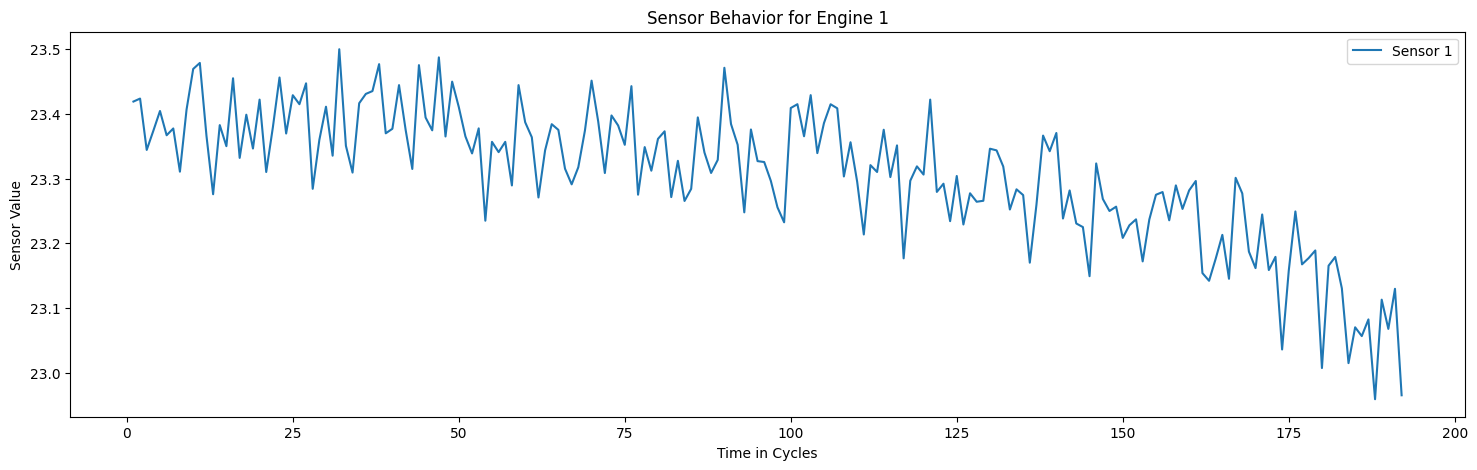

In [14]:
plt.figure(figsize=(18, 5))
plt.plot(engine_1_data['time_in_cycles'], engine_1_data['sensor_21'], label='Sensor 1')

plt.xlabel("Time in Cycles")
plt.ylabel("Sensor Value")
plt.title("Sensor Behavior for Engine 1")
plt.legend()
plt.show()

In [15]:
#checking if the useful sensors are across all egines and not just 1
data_std = df.drop(columns=['unit_number', 'time_in_cycles']).std()
useless_columns = data_std[data_std < 1e-5].index.tolist()
useless_columns

['op_setting_3',
 'sensor_1',
 'sensor_5',
 'sensor_10',
 'sensor_16',
 'sensor_18',
 'sensor_19']

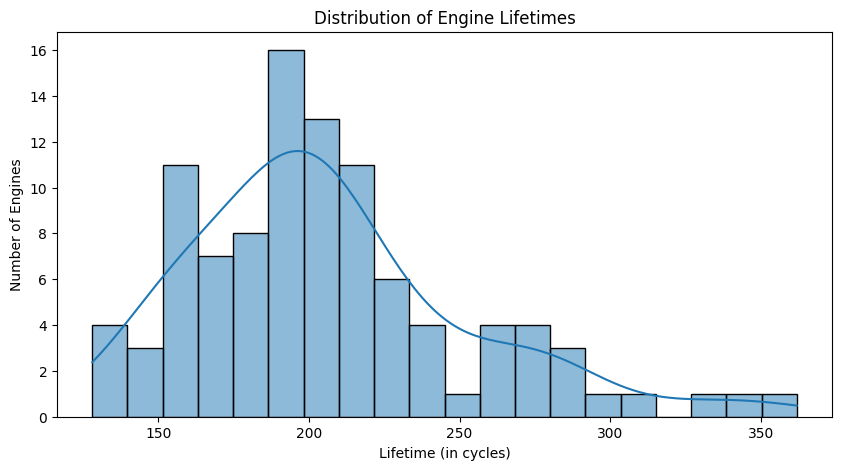

In [16]:
#max cycle for each engine
lifetimes = df.groupby('unit_number')['time_in_cycles'].max()

# Plot a histogram of the lifetimes
plt.figure(figsize=(10, 5))
sns.histplot(lifetimes, bins=20, kde=True)
plt.xlabel("Lifetime (in cycles)")
plt.ylabel("Number of Engines")
plt.title("Distribution of Engine Lifetimes")
plt.show()

In [17]:
#most common lifetime: 200
#4 engines failed early(around 150)
# and also some engines are outliers last long (around 350)
#it is a rightly skewed bell curve, most engines have typical lifespan of 200 cycles

In [18]:

useful_sensors = [
    'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9',
    'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17',
    'sensor_20', 'sensor_21'
]
feature_columns = ['op_setting_1', 'op_setting_2', 'op_setting_3'] + useful_sensors

In [19]:
train_df = df[feature_columns]

In [20]:
scaler = MinMaxScaler()

In [21]:
df_normalized = pd.DataFrame(scaler.fit_transform(train_df), columns=train_df.columns)

In [22]:
df.describe()

,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,5.329200e-15,...,0.737553,0.071919,19.076176,0.037505,3.469531e-18,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


In [23]:
df_normalized.describe()

,op_setting_1,op_setting_2,op_setting_3,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.0,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000
mean,0.499490,0.501959,0.0,0.443052,0.424746,0.450435,0.566459,0.297957,0.195248,0.411410,0.580697,0.317871,0.226095,0.451118,0.434221,0.524241,0.546127
std,0.125708,0.244218,0.0,0.150618,0.133664,0.151935,0.142527,0.107554,0.099089,0.158981,0.157261,0.105763,0.098442,0.144306,0.129064,0.140114,0.149476
min,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.413793,0.333333,0.0,0.335843,0.331807,0.339467,0.476651,0.227273,0.140761,0.297619,0.484009,0.235294,0.171870,0.346287,0.333333,0.434109,0.452361
50%,0.500000,0.500000,0.0,0.430723,0.415522,0.435348,0.578100,0.287879,0.174684,0.392857,0.594883,0.308824,0.209516,0.438630,0.416667,0.534884,0.557443
75%,0.586207,0.750000,0.0,0.539157,0.508829,0.545324,0.669887,0.363636,0.213991,0.505952,0.695096,0.382353,0.249613,0.541362,0.500000,0.627907,0.652582
max,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [24]:

df_normalized['unit_number'] = df['unit_number']
df_normalized['time_in_cycles'] = df['time_in_cycles']

max_cycles = df.groupby('unit_number')['time_in_cycles'].max().reset_index()
max_cycles.columns = ['unit_number', 'max_cycles']

df_merged = pd.merge(df_normalized, max_cycles, on='unit_number')

df_merged['RUL'] = df_merged['max_cycles'] - df_merged['time_in_cycles']

rul = df_merged['RUL']
train_features = df_merged.drop(columns=['unit_number', 'time_in_cycles', 'max_cycles', 'RUL'])


In [25]:
# this is what the lstm model needs to predict (the rul) UP

In [26]:
train_features.head()


,op_setting_1,op_setting_2,op_setting_3,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
0,0.459770,0.166667,0.0,0.183735,0.406802,0.309757,0.726248,0.242424,0.109755,0.369048,0.633262,0.205882,0.199608,0.363986,0.333333,0.713178,0.724662
1,0.609195,0.250000,0.0,0.283133,0.453019,0.352633,0.628019,0.212121,0.100242,0.380952,0.765458,0.279412,0.162813,0.411312,0.333333,0.666667,0.731014
2,0.252874,0.750000,0.0,0.343373,0.369523,0.370527,0.710145,0.272727,0.140043,0.250000,0.795309,0.220588,0.171793,0.357445,0.166667,0.627907,0.621375
3,0.540230,0.500000,0.0,0.343373,0.256159,0.331195,0.740741,0.318182,0.124518,0.166667,0.889126,0.294118,0.174889,0.166603,0.333333,0.573643,0.662386
4,0.390805,0.333333,0.0,0.349398,0.257467,0.404625,0.668277,0.242424,0.149960,0.255952,0.746269,0.235294,0.174734,0.402078,0.416667,0.589147,0.704502


In [27]:
rul

0        191
1        190
2        189
3        188
4        187
        ... 
20626      4
20627      3
20628      2
20629      1
20630      0
Name: RUL, Length: 20631, dtype: int64

In [28]:
import numpy as np

def create_sequences(features, labels, sequence_length=30):
    X, y = [], []
    
    for unit_num in features['unit_number'].unique():
        unit_features = features[features['unit_number'] == unit_num].drop(columns=['unit_number'])
        unit_labels = labels[features['unit_number'] == unit_num]

        for i in range(len(unit_features) - sequence_length + 1):
            X.append(unit_features.iloc[i:i + sequence_length].values)

            y.append(unit_labels.iloc[i + sequence_length - 1])

    return np.array(X), np.array(y)

features_with_unit = df_merged.drop(columns=['time_in_cycles', 'max_cycles', 'RUL'])

sequence_length = 30

X_train, y_train = create_sequences(features_with_unit, rul, sequence_length)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")

Shape of X_train: (17731, 30, 17)
Shape of y_train: (17731,)


In [29]:
n_timesteps = X_train.shape[1]
n_features = X_train.shape[2]

In [30]:
n_timesteps

30

In [31]:
n_features

17

In [37]:
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(n_timesteps, n_features)))
model.add(Dropout(0.2))
model.add(LSTM(units=50))
model.add(Dropout(0.2))
model.add(Dense(units=1))

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [38]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 50)         │        13,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,851 (132.23 KB)

 Trainable params: 33,851 (132.23 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [40]:
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=1)

print("Model training complete!")

Epoch 1/20


444/444 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 8838.4229 - val_loss: 11097.9004
Epoch 2/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 6234.6431 - val_loss: 8644.1592
Epoch 3/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 4783.6328 - val_loss: 7139.5811
Epoch 4/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 4007.7456 - val_loss: 6272.7891
Epoch 5/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 3663.8921 - val_loss: 5814.2900
Epoch 6/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 3533.7229 - val_loss: 5595.3394
Epoch 7/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 3504.9473 - val_loss: 5502.3584
Epoch 8/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 3472.6558 - val_loss: 5451.3442
Epoch 9/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 3492.5239 - val_loss: 5440.6411
Epoch 10/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 3490.9202 - val_loss: 5443.2021
Epoch 11/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 3488.1384 - val_l

In [41]:
test_df = pd.read_csv('dataset/test_FD001.txt', sep='\s+', header=None, names=column_names)
true_rul = pd.read_csv('dataset/RUL_FD001.txt', header=None)

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1903/1689744761.py:1: SyntaxWarning: invalid escape sequence '\s'
  test_df = pd.read_csv('dataset/test_FD001.txt', sep='\s+', header=None, names=column_names)


In [42]:
feature_columns = ['op_setting_1', 'op_setting_2', 'op_setting_3'] + useful_sensors
test_features = test_df[feature_columns]

In [43]:
test_normalized = pd.DataFrame(scaler.transform(test_features), columns=feature_columns)

In [44]:
sequence_length = 30
X_test = []
for unit_num in test_df['unit_number'].unique():
    unit_data = test_normalized[test_df['unit_number'] == unit_num]
    X_test.append(unit_data.iloc[-sequence_length:].values)

X_test = np.array(X_test)
y_test = true_rul.values.flatten()

print(f"Shape of X_test: {X_test.shape}")

Shape of X_test: (100, 30, 17)


In [45]:
y_pred = model.predict(X_test).flatten()

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


In [46]:
from sklearn.metrics import mean_squared_error

# Calculate the RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Root Mean Square Error (RMSE) on Test Data: {rmse}")

Root Mean Square Error (RMSE) on Test Data: 22.278070123941742


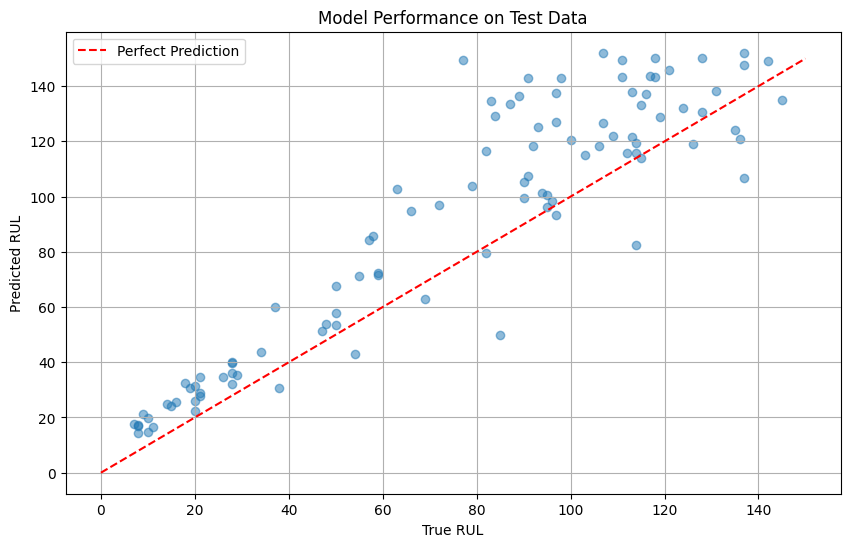

In [47]:
import matplotlib.pyplot as plt

# Plot true RUL vs. predicted RUL
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([0, 150], [0, 150], 'r--', label='Perfect Prediction') # A line for reference
plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("Model Performance on Test Data")
plt.legend()
plt.grid(True)
plt.show()

In [48]:
#fedavg

In [49]:
client_data = []

In [50]:
features_with_unit = df_merged.drop(columns=['time_in_cycles', 'max_cycles', 'RUL'])
rul = df_merged['RUL']
sequence_length = 30

In [51]:
for unit_num in df_merged['unit_number'].unique():
    unit_features_df = features_with_unit[features_with_unit['unit_number'] == unit_num]
    unit_rul_df = rul[features_with_unit['unit_number'] == unit_num]

    unit_features_df = unit_features_df.drop(columns=['unit_number'])

    X_client, y_client = [], []
    for i in range(len(unit_features_df) - sequence_length + 1):
        X_client.append(unit_features_df.iloc[i:i + sequence_length].values)
        y_client.append(unit_rul_df.iloc[i + sequence_length - 1])

    if len(X_client) > 0:
        client_data.append((np.array(X_client), np.array(y_client)))

print(f"Number of clients (engines): {len(client_data)}")
print(f"Shape of data for the first client: {client_data[0][0].shape}, {client_data[0][1].shape}")

Number of clients (engines): 100
Shape of data for the first client: (163, 30, 17), (163,)


In [52]:
from tensorflow.keras.models import clone_model

def build_model():
    model = Sequential()
    model.add(LSTM(units=50, return_sequences=True, input_shape=(n_timesteps, n_features)))
    model.add(Dropout(0.2))
    model.add(LSTM(units=50))
    model.add(Dropout(0.2))
    model.add(Dense(units=1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

global_model = build_model()

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## fedavg

In [ ]:
import numpy as np

# Hyperparames for FedAvg
COMMUNICATION_ROUNDS = 50
LOCAL_EPOCHS = 5 
NUM_CLIENTS = len(client_data)
local_model = build_model()

for comm_round in range(COMMUNICATION_ROUNDS):
    print(f" Communication Round {comm_round + 1}/{COMMUNICATION_ROUNDS} ")

    # current weights 
    global_weights = global_model.get_weights()
    
    # hold local model updates
    local_weight_updates = []

    # train client too
    for client_id in range(NUM_CLIENTS):
        local_model.set_weights(global_weights)
        X_client, y_client = client_data[client_id]

        local_model.fit(X_client, y_client, epochs=LOCAL_EPOCHS, verbose=0, batch_size=32)
        
        # Get the updated weights and add them to our list
        local_weight_updates.append(local_model.get_weights())

    #  FedAvg
    # average of all the local weight updates 
    average_weights = list()
    for weights_list_tuple in zip(*local_weight_updates):
        layer_mean = np.mean(np.array(weights_list_tuple), axis=0)
        average_weights.append(layer_mean)
    
    # Update the global model with the new, averaged weights
    global_model.set_weights(average_weights)

print("Federated training complete!")

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


--- Communication Round 1/50 ---
--- Communication Round 2/50 ---
--- Communication Round 3/50 ---
--- Communication Round 4/50 ---
--- Communication Round 5/50 ---
--- Communication Round 6/50 ---
--- Communication Round 7/50 ---
--- Communication Round 8/50 ---
--- Communication Round 9/50 ---
--- Communication Round 10/50 ---
--- Communication Round 11/50 ---
--- Communication Round 12/50 ---
--- Communication Round 13/50 ---
--- Communication Round 14/50 ---
--- Communication Round 15/50 ---
--- Communication Round 16/50 ---
--- Communication Round 17/50 ---
--- Communication Round 18/50 ---
--- Communication Round 19/50 ---
--- Communication Round 20/50 ---
--- Communication Round 21/50 ---
--- Communication Round 22/50 ---
--- Communication Round 23/50 ---
--- Communication Round 24/50 ---
--- Communication Round 25/50 ---
--- Communication Round 26/50 ---
--- Communication Round 27/50 ---
--- Communication Round 28/50 ---
--- Communication Round 29/50 ---
--- Communication Round

In [49]:
y_pred_fl = global_model.predict(X_test).flatten()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


In [50]:
rmse_fl = np.sqrt(mean_squared_error(y_test, y_pred_fl))

# Print both scores for a direct comparison
print(f"Centralized Baseline RMSE: {rmse}") # The variable from your first evaluation
print(f"Federated Model RMSE:      {rmse_fl}")

Centralized Baseline RMSE: 18.988342724519907
Federated Model RMSE:      41.56989184738306


## FEDPROX

In [56]:
def create_client_data(sequence_length=30):
    """
    Loads and prepares the training data, splitting it by engine (client).
    We re-use the 'scaler' object from our centralized training.
    """
    print("Loading and preparing client data...")
    # Load the original training data
    train_df = pd.read_csv('dataset/train_FD001.txt', sep='\s+', header=None)
    # --- THIS IS THE FIX ---
    # 1. Drop any extra columns that were created from trailing spaces
    train_df.dropna(axis=1, how='all', inplace=True)
    # 2. Drop any rows that might have missing values (just in case)
    train_df.dropna(axis=0, how='any', inplace=True)
    # -----------------------
    # Define column names based on the readme file
    column_names = [
        'unit_number', 'time_in_cycles', 'op_setting_1', 'op_setting_2', 'op_setting_3',
        'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6',
        'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12',
        'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18',
        'sensor_19', 'sensor_20', 'sensor_21'
    ]
    train_df.columns = column_names
    
    # Calculate RUL
    max_cycles = train_df.groupby('unit_number')['time_in_cycles'].max().reset_index()
    max_cycles.columns = ['unit_number', 'max_cycles']
    train_df = pd.merge(train_df, max_cycles, on='unit_number')
    train_df['RUL'] = train_df['max_cycles'] - train_df['time_in_cycles']
    
    # --- IMPORTANT ---
    # Use the EXISTING scaler from your centralized run
    # (Make sure the 'scaler' variable is in your notebook's memory)
    useful_sensors = [
        'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9',
        'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17',
        'sensor_20', 'sensor_21'
    ]
    feature_cols = ['op_setting_1', 'op_setting_2', 'op_setting_3'] + useful_sensors
    train_df[feature_cols] = scaler.transform(train_df[feature_cols])

    client_data = []
    # Create sequences for each client (engine)
    for unit_num in train_df['unit_number'].unique():
        unit_df = train_df[train_df['unit_number'] == unit_num]
        
        features = unit_df[feature_cols].values
        labels = unit_df['RUL'].values
        
        X_client, y_client = [], []
        for i in range(len(unit_df) - sequence_length + 1):
            X_client.append(features[i:i + sequence_length])
            y_client.append(labels[i + sequence_length - 1])
        
        if len(X_client) > 0:
            # Create a TensorFlow dataset for easy batching
            client_dataset = tf.data.Dataset.from_tensor_slices((
                np.array(X_client, dtype=np.float32), 
                np.array(y_client, dtype=np.float32)
            )).batch(32).shuffle(len(X_client))
            
            client_data.append(client_dataset)

    print(f"Prepared data for {len(client_data)} clients.")
    return client_data

# Create the client data
client_data = create_client_data()

<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1903/1518384087.py:8: SyntaxWarning: invalid escape sequence '\s'
  train_df = pd.read_csv('dataset/train_FD001.txt', sep='\s+', header=None)


Loading and preparing client data...
Prepared data for 100 clients.


In [53]:
@tf.function
def fedprox_train_step(local_model, global_weights, X_batch, y_batch, mu=0.01):
    """
    A single training step (on one batch) for a FedProx client.
    """
    loss_fn = tf.keras.losses.MeanSquaredError()
    optimizer = local_model.optimizer

    with tf.GradientTape() as tape:
        # 1. Make a prediction
        y_pred = local_model(X_batch, training=True)
        
        # 2. Calculate the standard MSE loss
        loss = loss_fn(y_batch, y_pred)
        
        # 3. Calculate the FedProx proximal term
        proximal_term = 0.0
        # We zip global and local weights together
        for w_local, w_global in zip(local_model.trainable_variables, global_weights):
            proximal_term += tf.nn.l2_loss(w_local - w_global)
            
        # 4. Add the penalty to the standard loss
        total_loss = loss + mu * proximal_term

    # Calculate gradients and apply them
    grads = tape.gradient(total_loss, local_model.trainable_variables)
    optimizer.apply_gradients(zip(grads, local_model.trainable_variables))

In [54]:
#new one
# --- Hyperparameters ---
COMMUNICATION_ROUNDS = 100  # Let's keep 100 rounds
LOCAL_EPOCHS = 5            # Back to 5, which we know works best
MU = 0.001                  # The loose leash
CLIENT_FRACTION = 0.2       # --- NEW --- We will sample 20% (20 clients) per round

# --- Initialize Models ---
# (Make sure to re-run Cell 4 to reset the tf.function)
global_model = build_model()
local_model = build_model()

# --- FedProx Training Loop with Client Sampling ---
print(f"--- Starting FedProx Training with {CLIENT_FRACTION*100}% Client Sampling ---")

n_clients = len(client_data)
clients_to_sample = int(n_clients * CLIENT_FRACTION)

for r in range(COMMUNICATION_ROUNDS):
    round_start_time = time.time()
    global_weights = global_model.get_weights()
    local_weight_updates = []
    
    # --- THIS IS THE NEW PART ---
    # Randomly select a subset of clients for this round
    selected_clients_indices = np.random.choice(range(n_clients), clients_to_sample, replace=False)
    # ---------------------------

    for client_idx in selected_clients_indices:
        # Set local model to match global model
        local_model.set_weights(global_weights)
        
        # Get the data for the selected client
        client_dataset = client_data[client_idx]
        
        # Train using the custom FedProx step
        for e in range(LOCAL_EPOCHS):
            for (X_batch, y_batch) in client_dataset:
                fedprox_train_step(local_model, global_weights, X_batch, y_batch, mu=MU)
        
        # Collect the updated weights
        local_weight_updates.append(local_model.get_weights())

    # --- Federated Averaging (Server-side) ---
    # The average is now only over the selected clients
    average_weights = list()
    for weights_list_tuple in zip(*local_weight_updates):
        layer_mean = np.mean(np.array(weights_list_tuple), axis=0)
        average_weights.append(layer_mean)
    
    # Update global model
    global_model.set_weights(average_weights)
    
    round_time = time.time() - round_start_time
    print(f"Round {r+1}/{COMMUNICATION_ROUNDS} complete in {round_time:.2f}s")

print("--- FedProx Training with Client Sampling Complete ---")

--- Starting FedProx Training with 20.0% Client Sampling ---
Round 1/100 complete in 20.65s
Round 2/100 complete in 10.87s
Round 3/100 complete in 8.57s
Round 4/100 complete in 8.29s
Round 5/100 complete in 7.20s
Round 6/100 complete in 7.18s
Round 7/100 complete in 7.70s
Round 8/100 complete in 7.26s
Round 9/100 complete in 6.37s
Round 10/100 complete in 6.82s
Round 11/100 complete in 7.00s
Round 12/100 complete in 6.00s
Round 13/100 complete in 6.58s
Round 14/100 complete in 6.11s
Round 15/100 complete in 6.71s
Round 16/100 complete in 6.32s
Round 17/100 complete in 6.44s
Round 18/100 complete in 6.69s
Round 19/100 complete in 6.24s
Round 20/100 complete in 6.63s
Round 21/100 complete in 6.67s
Round 22/100 complete in 6.71s
Round 23/100 complete in 6.35s
Round 24/100 complete in 6.57s
Round 25/100 complete in 6.28s
Round 26/100 complete in 6.18s
Round 27/100 complete in 6.61s
Round 28/100 complete in 6.18s
Round 29/100 complete in 5.96s
Round 30/100 complete in 6.77s
Round 31/100 com

2025-11-16 12:14:34.820483: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Round 64/100 complete in 6.40s
Round 65/100 complete in 6.61s
Round 66/100 complete in 6.31s
Round 67/100 complete in 6.18s
Round 68/100 complete in 6.20s
Round 69/100 complete in 5.67s
Round 70/100 complete in 6.84s
Round 71/100 complete in 7.11s
Round 72/100 complete in 7.12s
Round 73/100 complete in 5.79s
Round 74/100 complete in 6.86s
Round 75/100 complete in 6.48s
Round 76/100 complete in 6.31s
Round 77/100 complete in 6.19s
Round 78/100 complete in 6.19s
Round 79/100 complete in 5.93s
Round 80/100 complete in 6.29s
Round 81/100 complete in 6.73s
Round 82/100 complete in 6.72s
Round 83/100 complete in 6.87s
Round 84/100 complete in 6.55s
Round 85/100 complete in 6.17s
Round 86/100 complete in 6.14s
Round 87/100 complete in 6.60s
Round 88/100 complete in 6.56s
Round 89/100 complete in 6.08s
Round 90/100 complete in 7.03s
Round 91/100 complete in 5.97s
Round 92/100 complete in 5.80s
Round 93/100 complete in 6.87s
Round 94/100 complete in 6.16s
Round 95/100 complete in 6.21s
Round 96

In [49]:
# --- Hyperparameters ---
COMMUNICATION_ROUNDS = 100
LOCAL_EPOCHS = 1
MU = 0.001 # The FedProx "leash" strength

# --- Initialize Models ---
# Get input shape from the first client's data
sample_X, _ = next(iter(client_data[0]))
n_timesteps = sample_X.shape[1]
n_features = sample_X.shape[2]

global_model = build_model()
local_model = build_model()

# --- FedProx Training Loop ---
print(f"--- Starting FedProx Training ({COMMUNICATION_ROUNDS} Rounds) ---")

for r in range(COMMUNICATION_ROUNDS):
    round_start_time = time.time()
    global_weights = global_model.get_weights()
    local_weight_updates = []

    for client_dataset in client_data:
        # Set local model to match global model
        local_model.set_weights(global_weights)
        
        # Train using the custom FedProx step
        for e in range(LOCAL_EPOCHS):
            for (X_batch, y_batch) in client_dataset:
                fedprox_train_step(local_model, global_weights, X_batch, y_batch, mu=MU)
        
        # Collect the updated weights
        local_weight_updates.append(local_model.get_weights())

    # --- Federated Averaging (Server-side) ---
    average_weights = list()
    for weights_list_tuple in zip(*local_weight_updates):
        layer_mean = np.mean(np.array(weights_list_tuple), axis=0)
        average_weights.append(layer_mean)
    
    # Update global model
    global_model.set_weights(average_weights)
    
    round_time = time.time() - round_start_time
    print(f"Round {r+1}/{COMMUNICATION_ROUNDS} complete in {round_time:.2f}s")

print("--- FedProx Training Complete ---")

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


--- Starting FedProx Training (100 Rounds) ---


2025-11-16 11:46:17.497474: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-11-16 11:46:18.341828: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-11-16 11:46:19.186911: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-11-16 11:46:22.647275: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-11-16 11:46:28.251543: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-11-16 11:46:33.309672: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-11-16 11:46:42.451343: I tensorflow/core/framework/local_rendezvous.cc:407] L

Round 1/100 complete in 32.53s


2025-11-16 11:46:49.595282: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


...

Round 21/100 complete in 6.73s
Round 22/100 complete in 6.65s
Round 23/100 complete in 6.61s
Round 24/100 complete in 6.59s
Round 25/100 complete in 6.63s
Round 26/100 complete in 6.64s
Round 27/100 complete in 6.52s
Round 28/100 complete in 6.55s
Round 29/100 complete in 6.61s
Round 30/100 complete in 6.58s
Round 31/100 complete in 6.73s
Round 32/100 complete in 6.77s
Round 33/100 complete in 6.57s
Round 34/100 complete in 6.65s
Round 35/100 complete in 6.73s
Round 36/100 complete in 6.58s
Round 37/100 complete in 6.71s
Round 38/100 complete in 6.74s
Round 39/100 complete in 6.57s
Round 40/100 complete in 6.58s


2025-11-16 11:51:15.006081: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Round 41/100 complete in 6.59s
Round 42/100 complete in 6.69s
Round 43/100 complete in 6.70s
Round 44/100 complete in 6.58s
Round 45/100 complete in 6.66s
Round 46/100 complete in 6.56s
Round 47/100 complete in 6.59s
Round 48/100 complete in 6.58s
Round 49/100 complete in 6.67s
Round 50/100 complete in 6.62s
Round 51/100 complete in 6.63s
Round 52/100 complete in 6.62s
Round 53/100 complete in 6.57s
Round 54/100 complete in 6.67s
Round 55/100 complete in 6.72s
Round 56/100 complete in 6.55s
Round 57/100 complete in 6.67s
Round 58/100 complete in 6.66s
Round 59/100 complete in 6.61s
Round 60/100 complete in 6.58s
Round 61/100 complete in 6.53s
Round 62/100 complete in 6.59s
Round 63/100 complete in 6.86s
Round 64/100 complete in 6.51s
Round 65/100 complete in 6.59s
Round 66/100 complete in 6.77s
Round 67/100 complete in 6.70s
Round 68/100 complete in 6.77s
Round 69/100 complete in 6.60s
Round 70/100 complete in 6.63s
Round 71/100 complete in 6.66s
Round 72/100 complete in 6.58s
Round 73

2025-11-16 11:55:46.887134: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Round 82/100 complete in 6.85s
Round 83/100 complete in 6.79s
Round 84/100 complete in 6.67s
Round 85/100 complete in 6.69s
Round 86/100 complete in 6.75s
Round 87/100 complete in 6.68s
Round 88/100 complete in 6.75s
Round 89/100 complete in 6.88s
Round 90/100 complete in 6.71s
Round 91/100 complete in 6.78s
Round 92/100 complete in 6.80s
Round 93/100 complete in 6.57s
Round 94/100 complete in 6.74s
Round 95/100 complete in 6.66s
Round 96/100 complete in 6.59s
Round 97/100 complete in 6.64s
Round 98/100 complete in 6.70s
Round 99/100 complete in 6.74s
Round 100/100 complete in 6.56s
--- FedProx Training Complete ---


In [55]:
from sklearn.metrics import mean_squared_error

print("Evaluating FedProx model...")

# Use the X_test and y_test from your centralized run
# (They should still be in your notebook's memory)
y_pred_fl = global_model.predict(X_test).flatten()

# Calculate the RMSE
rmse_fedprox = np.sqrt(mean_squared_error(y_test, y_pred_fl))

# Use the 'rmse' variable from your centralized run
print(f"Centralized Baseline RMSE: {rmse:.2f}")
print(f"FedProx Model RMSE:          {rmse_fedprox:.2f}")

Evaluating FedProx model...
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x718c5f015d00> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Centralized Baseline RMSE: 19.53
FedProx Model RMSE:          41.58


## ------------------------------------------------------------------------------------------------------------------------------------

## that new model

In [59]:
from tensorflow.keras.layers import BatchNormalization

def build_deep_lstm_model(n_timesteps, n_features):
    """
    Builds a deep, 3-layer LSTM model with Batch Normalization.
    This architecture is based on your screenshot.
    """
    model = Sequential()
    
    # Input Layer (LSTM 1)
    # We use return_sequences=True to feed the next LSTM layer
    model.add(LSTM(units=100, return_sequences=True, input_shape=(n_timesteps, n_features)))
    model.add(BatchNormalization())
    
    # Hidden Layer (LSTM 2)
    model.add(LSTM(units=50, return_sequences=True))
    model.add(Dropout(0.2))
    
    # Hidden Layer (LSTM 3)
    # This is the last LSTM, so return_sequences=False
    model.add(LSTM(units=10))
    model.add(Dropout(0.2))
    
    # "Smart" Dense Head
    model.add(Dense(units=100, activation='relu'))
    model.add(Dense(units=1)) # Final RUL prediction
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    
    print("Deep LSTM model architecture built successfully.")
    model.summary()
    
    return model

In [60]:
# Get input shapes
n_timesteps = X_train.shape[1]
n_features = X_train.shape[2]

# Build the new deep model
centralized_deep_model = build_deep_lstm_model(n_timesteps, n_features)

print("Training centralized DEEP LSTM baseline...")
# This may take longer - let's train for more epochs
history_deep = centralized_deep_model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.2, verbose=1)

# Evaluate the NEW baseline
print("\n--- Centralized DEEP LSTM Model Evaluation ---")
y_pred_deep = centralized_deep_model.predict(X_test).flatten()
rmse_deep_centralized = np.sqrt(mean_squared_error(y_test, y_pred_deep))
print(f"Centralized DEEP LSTM Baseline RMSE: {rmse_deep_centralized:.2f}")

Deep LSTM model architecture built successfully.


/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_16 (LSTM)                  │ (None, 30, 100)        │        47,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 100)        │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_17 (LSTM)                  │ (None, 30, 50)         │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_18 (LSTM)                  │ (None, 10)             │         2,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 100)            │         1,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,441 (318.13 KB)

 Trainable params: 81,241 (317.35 KB)

 Non-trainable params: 200 (800.00 B)

Training centralized DEEP LSTM baseline...
Epoch 1/30


2025-11-16 12:51:30.765326: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 28935360 exceeds 10% of free system memory.


444/444 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - loss: 5110.6567 - val_loss: 4035.4658
Epoch 2/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 1425.2621 - val_loss: 6660.7622
Epoch 3/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 1262.1437 - val_loss: 5514.3652
Epoch 4/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 1120.8489 - val_loss: 3189.0251
Epoch 5/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 1011.3013 - val_loss: 3356.0029
Epoch 6/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 964.2360 - val_loss: 1878.1318
Epoch 7/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 887.7957 - val_loss: 2160.3560
Epoch 8/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 881.4819 - val_loss: 2153.4829
Epoch 9/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 804.4033 - val_loss: 2004.8169
Epoch 10/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 777.9471 - val_loss: 2043.3505
Epoch 11/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 740.0598 - v

In [61]:
# --- Hyperparameters ---
COMMUNICATION_ROUNDS = 50
LOCAL_EPOCHS = 5

# --- Initialize DEEP Models ---
global_model = build_deep_lstm_model(n_timesteps, n_features)
local_model = build_deep_lstm_model(n_timesteps, n_features)

# --- FedAvg Loop (using the existing 'client_data') ---
print("--- Starting Federated Training (FedAvg) with DEEP LSTM Model ---")
# (This will take a long time, but it's the real experiment)
for r in range(COMMUNICATION_ROUNDS):
    round_start_time = time.time()
    global_weights = global_model.get_weights()
    local_weight_updates = []

    for client_dataset in client_data:
        local_model.set_weights(global_weights)
        
        # Use simple FedAvg
        local_model.fit(client_dataset, epochs=LOCAL_EPOCHS, verbose=0)
        
        local_weight_updates.append(local_model.get_weights())

    # --- Aggregation ---
    average_weights = list()
    for weights_list_tuple in zip(*local_weight_updates):
        layer_mean = np.mean(np.array(weights_list_tuple), axis=0)
        average_weights.append(layer_mean)
    
    global_model.set_weights(average_weights)
    round_time = time.time() - round_start_time
    print(f"Round {r+1}/{COMMUNICATION_ROUNDS} complete in {round_time:.2f}s")

# --- Final Evaluation ---
print("\n--- Federated DEEP LSTM Model Evaluation ---")
y_pred_fl_deep = global_model.predict(X_test).flatten()
rmse_fl_deep = np.sqrt(mean_squared_error(y_test, y_pred_fl_deep))

print(f"Centralized DEEP LSTM RMSE: {rmse_deep_centralized:.2f}")
print(f"Federated DEEP LSTM RMSE:   {rmse_fl_deep:.2f}")

Deep LSTM model architecture built successfully.


/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_19 (LSTM)                  │ (None, 30, 100)        │        47,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 100)        │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_20 (LSTM)                  │ (None, 30, 50)         │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_21 (LSTM)                  │ (None, 10)             │         2,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 100)            │         1,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,441 (318.13 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_22 (LSTM)                  │ (None, 30, 100)        │        47,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 30, 100)        │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_23 (LSTM)                  │ (None, 30, 50)         │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_24 (LSTM)                  │ (None, 10)             │         2,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 100)            │         1,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,441 (318.13 KB)

 Trainable params: 81,241 (317.35 KB)

 Non-trainable params: 200 (800.00 B)

--- Starting Federated Training (FedAvg) with DEEP LSTM Model ---
Round 1/50 complete in 63.25s
Round 2/50 complete in 59.38s
Round 3/50 complete in 59.41s
Round 4/50 complete in 59.54s
Round 5/50 complete in 59.64s
Round 6/50 complete in 59.36s
Round 7/50 complete in 59.28s
Round 8/50 complete in 59.55s
Round 9/50 complete in 59.41s
Round 10/50 complete in 59.75s
Round 11/50 complete in 59.60s
Round 12/50 complete in 58.74s
Round 13/50 complete in 59.44s
Round 14/50 complete in 59.49s
Round 15/50 complete in 58.94s
Round 16/50 complete in 59.13s
Round 17/50 complete in 58.79s
Round 18/50 complete in 58.70s
Round 19/50 complete in 58.63s
Round 20/50 complete in 58.76s
Round 21/50 complete in 58.67s
Round 22/50 complete in 58.66s
Round 23/50 complete in 58.84s
Round 24/50 complete in 59.22s
Round 25/50 complete in 58.83s
Round 26/50 complete in 58.71s
Round 27/50 complete in 58.68s
Round 28/50 complete in 58.66s
Round 29/50 complete in 58.87s
Round 30/50 complete in 58.55s
Round 31/50 c

## cnn-bilstm hybrid

In [33]:
from tensorflow.keras.layers import Bidirectional, Conv1D, MaxPooling1D
from tensorflow.keras.optimizers import Adam  
def build_cnn_bilstm_model(n_timesteps, n_features):
    """
    Builds a hybrid CNN-BiLSTM model.
    """
    model = Sequential()
    
    # 1. CNN Feature Extractor
    model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(n_timesteps, n_features)))
    model.add(MaxPooling1D(pool_size=2))
    
    # 2. BiLSTM Layer
    model.add(Bidirectional(LSTM(units=50)))
    model.add(Dropout(0.2))
    
    # 3. Dense Head
    model.add(Dense(units=1)) # Final RUL prediction
    
    # Use the slow, stable learning rate
    optimizer = Adam(learning_rate=0.0001)
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    
    print("Hybrid CNN-BiLSTM model architecture built successfully.")
    model.summary()
    
    return model

In [53]:
# Get input shapes
n_timesteps = X_train.shape[1]
n_features = X_train.shape[2]

# Build the new model
centralized_hybrid_model = build_cnn_bilstm_model(n_timesteps, n_features)

print("Training centralized CNN-BiLSTM baseline...")
# We need to train this for a while
history_hybrid = centralized_hybrid_model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.2, verbose=1)

# Evaluate the NEW baseline
print("\n--- Centralized CNN-BiLSTM Model Evaluation ---")
y_pred_hybrid = centralized_hybrid_model.predict(X_test).flatten()
rmse_hybrid_centralized = np.sqrt(mean_squared_error(y_test, y_pred_hybrid))
print(f"Centralized CNN-BiLSTM Baseline RMSE: {rmse_hybrid_centralized:.2f}")

Hybrid CNN-BiLSTM model architecture built successfully.


/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 28, 64)         │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 100)            │        46,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,429 (193.08 KB)

 Trainable params: 49,429 (193.08 KB)

 Non-trainable params: 0 (0.00 B)

Training centralized CNN-BiLSTM baseline...
Epoch 1/30


444/444 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 10167.0352 - val_loss: 13411.9766
Epoch 2/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 8756.7939 - val_loss: 12485.8887
Epoch 3/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 8084.8159 - val_loss: 11742.6816
Epoch 4/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 7514.7451 - val_loss: 11080.9414
Epoch 5/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6994.5117 - val_loss: 10444.6055
Epoch 6/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6514.8145 - val_loss: 9871.7314
Epoch 7/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 6072.8467 - val_loss: 9318.4834
Epoch 8/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 5650.9019 - val_loss: 8807.9443
Epoch 9/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 5250.6108 - val_loss: 8295.4443
Epoch 10/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 4873.9004 - val_loss: 7812.7866
Epoch 11/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 4498.9536 - val_loss: 7

In [57]:
# --- Hyperparameters ---
# --- Hyperparameters ---
COMMUNICATION_ROUNDS = 50
LOCAL_EPOCHS = 5
NUM_CLIENTS = len(client_data)

# --- Initialize HYBRID Models ---
# We use the models we just defined in the cell above
global_model = build_cnn_bilstm_model(n_timesteps, n_features)
local_model = build_cnn_bilstm_model(n_timesteps, n_features)

# --- This is the FedAvg Loop You Need ---
print(f"--- Starting Final Experiment (CNN-BiLSTM + FedAvg) ---")

for r in range(COMMUNICATION_ROUNDS):
    round_start_time = time.time()
    global_weights = global_model.get_weights()
    local_weight_updates = []

    # Iterate through all clients
    for client_dataset in client_data:
        # 1. Set local model to match global model
        local_model.set_weights(global_weights)
        
        # 2. Use simple .fit() for local training
        local_model.fit(client_dataset, epochs=LOCAL_EPOCHS, verbose=0)
        
        # 3. Collect the updated weights
        local_weight_updates.append(local_model.get_weights())

    # --- Aggregation (Server-side) ---
    average_weights = list()
    for weights_list_tuple in zip(*local_weight_updates):
        layer_mean = np.mean(np.array(weights_list_tuple), axis=0)
        average_weights.append(layer_mean)
    
    # Update global model
    global_model.set_weights(average_weights)
    round_time = time.time() - round_start_time
    print(f"Round {r+1}/{COMMUNICATION_ROUNDS} complete in {round_time:.2f}s")

print("--- Federated Training Complete ---")

# --- Final Evaluation ---
print("\n--- Final Experiment Evaluation ---")
y_pred_fl_hybrid = global_model.predict(X_test).flatten()
rmse_fl_hybrid = np.sqrt(mean_squared_error(y_test, y_pred_fl_hybrid))

# (Make sure 'rmse_hybrid_centralized' from Cell 2 is in memory)
print(f"Centralized CNN-BiLSTM RMSE: {rmse_hybrid_centralized:.2f}")
print(f"Federated CNN-BiLSTM RMSE:   {rmse_fl_hybrid:.2f}")

Hybrid CNN-BiLSTM model architecture built successfully.


/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_5 (Conv1D)               │ (None, 28, 64)         │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 100)            │        46,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,429 (193.08 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 28, 64)         │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ (None, 100)            │        46,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,429 (193.08 KB)

 Trainable params: 49,429 (193.08 KB)

 Non-trainable params: 0 (0.00 B)

--- Starting Final Experiment (CNN-BiLSTM + FedAvg) ---
Round 1/50 complete in 18.31s
Round 2/50 complete in 15.76s
Round 3/50 complete in 15.56s
Round 4/50 complete in 15.57s
Round 5/50 complete in 15.64s
Round 6/50 complete in 15.60s
Round 7/50 complete in 15.66s
Round 8/50 complete in 15.83s
Round 9/50 complete in 15.65s
Round 10/50 complete in 15.63s
Round 11/50 complete in 15.65s
Round 12/50 complete in 15.51s
Round 13/50 complete in 15.35s
Round 14/50 complete in 15.87s
Round 15/50 complete in 15.87s
Round 16/50 complete in 15.69s
Round 17/50 complete in 15.52s
Round 18/50 complete in 15.61s
Round 19/50 complete in 15.48s
Round 20/50 complete in 15.54s
Round 21/50 complete in 15.44s
Round 22/50 complete in 15.58s
Round 23/50 complete in 15.46s
Round 24/50 complete in 15.43s
Round 25/50 complete in 15.50s
Round 26/50 complete in 15.89s
Round 27/50 complete in 15.73s
Round 28/50 complete in 15.66s
Round 29/50 complete in 15.79s
Round 30/50 complete in 15.69s
Round 31/50 complete in